<a href="https://colab.research.google.com/github/sharvarimhaske/sharvari_mhaske-data-frames_project/blob/main/ASS_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [5]:
from google.colab import files
uploaded = files.upload()

Saving ford_car_dataset.csv to ford_car_dataset.csv


In [6]:
df = pd.read_csv("ford_car_dataset.csv")

In [7]:

df = pd.read_csv("ford_car_dataset.csv")
print("First 10 Rows")
display(df.head(10))
print("Last 5 Rows")
display(df.tail())
print("Shape of Dataset:", df.shape)
print("Data Types")
print(df.dtypes)
print("\nDataset Info")
df.info()


First 10 Rows


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


Last 5 Rows


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


Shape of Dataset: (17966, 9)
Data Types
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [8]:

print("Missing Values")
print(df.isnull().sum())
print("Total Missing Values =", df.isnull().sum().sum())
print("Duplicate Rows =", df.duplicated().sum())
df = df.drop_duplicates()
print("New Shape:", df.shape)


Missing Values
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
Total Missing Values = 0
Duplicate Rows = 154
New Shape: (17812, 9)


In [9]:

display(df.describe())
print("Price Mean =", df['price'].mean())
print("Price Median =", df['price'].median())
print("Price Minimum =", df['price'].min())
print("Price Maximum =", df['price'].max())
print("Mileage Mean =", df['mileage'].mean())
print("Mileage Median =", df['mileage'].median())
print("Mileage Minimum =", df['mileage'].min())
print("Mileage Maximum =", df['mileage'].max())
print("Year Mean =", df['year'].mean())
print("Year Median =", df['year'].median())
print("Year Minimum =", df['year'].min())
print("Year Maximum =", df['year'].max())

,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


Price Mean = 12269.556310352571
Price Median = 11288.0
Price Minimum = 495
Price Maximum = 54995
Mileage Mean = 23381.146362003143
Mileage Median = 18277.0
Mileage Minimum = 1
Mileage Maximum = 177644
Year Mean = 2016.8623961374353
Year Median = 2017.0
Year Minimum = 1996
Year Maximum = 2060


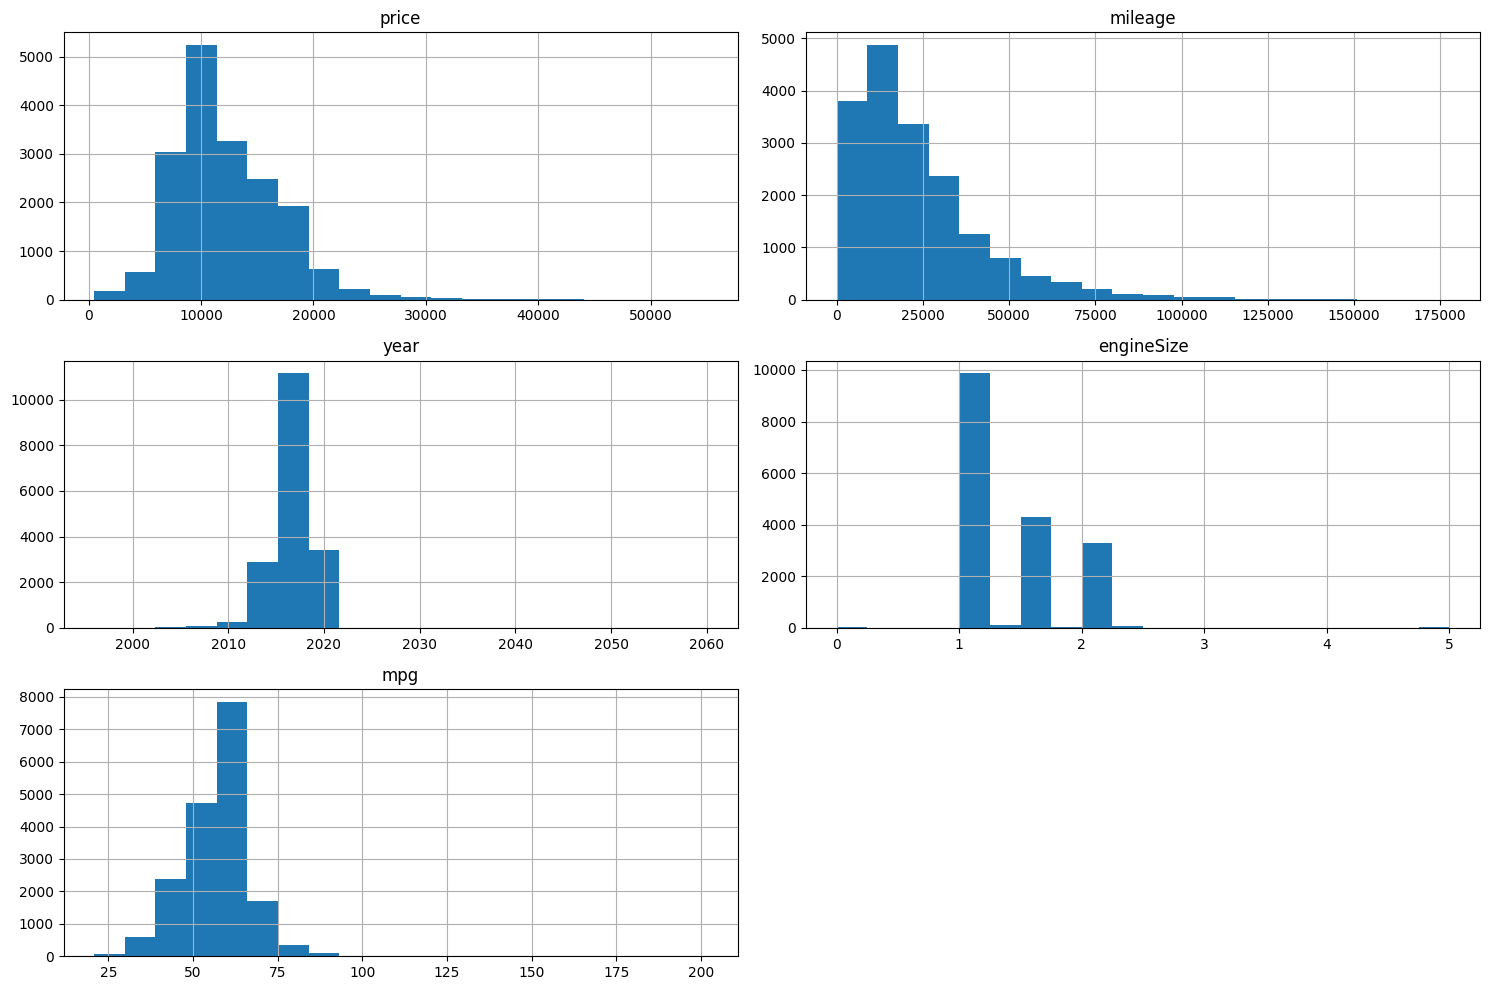

In [10]:
numeric_columns = ['price','mileage','year','engineSize','mpg']

df[numeric_columns].hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

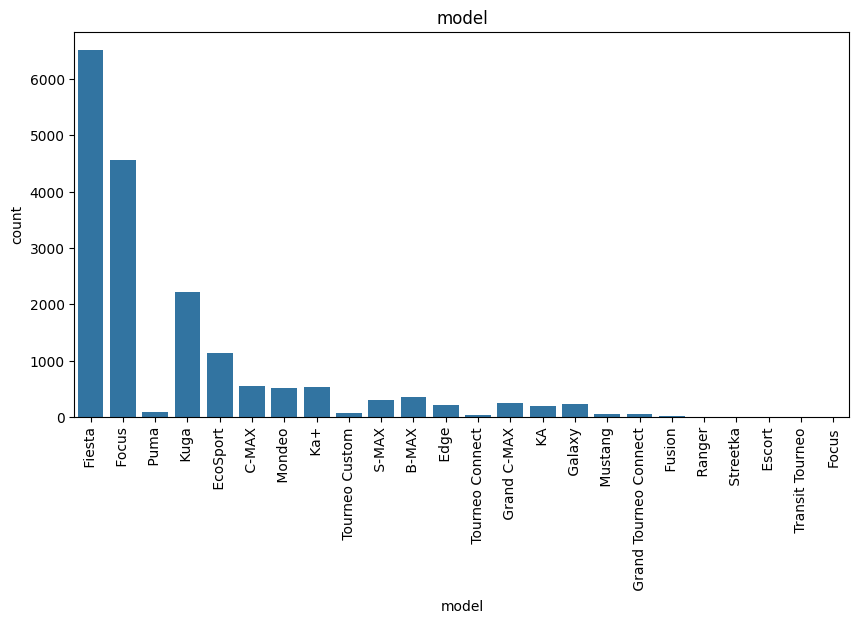

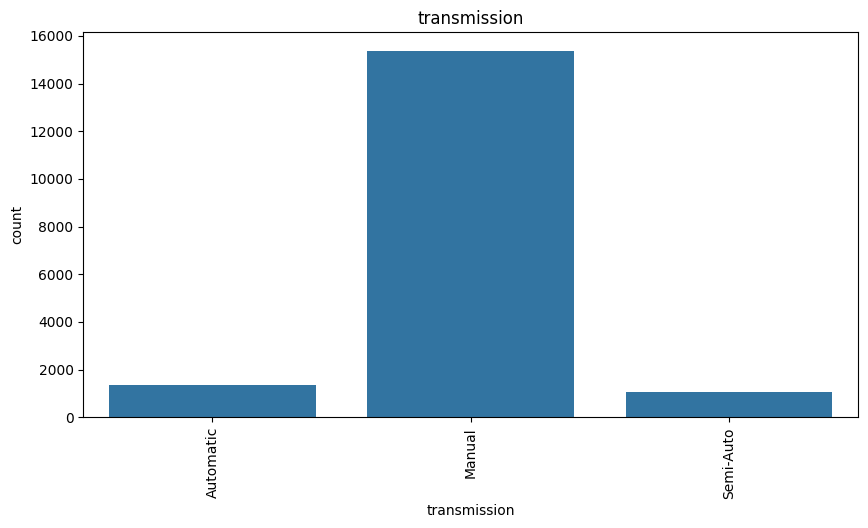

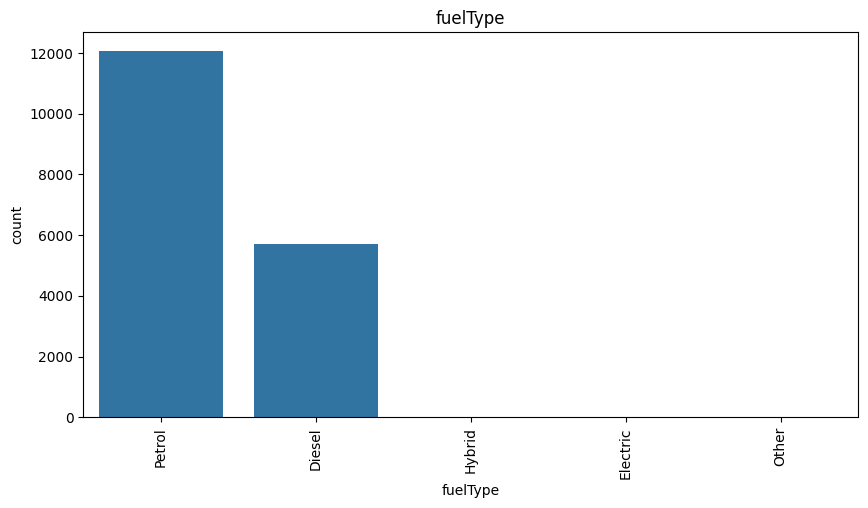

In [11]:
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()


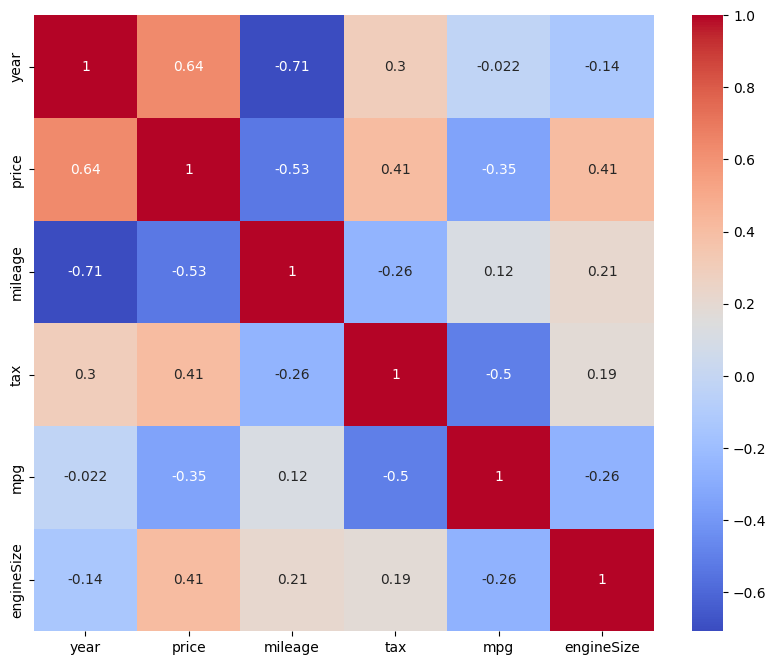

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()


In [13]:

y = df['price']


X = df.drop('price', axis=1)

print("Independent Features")
print(X.columns)

print("\nDependent Feature")
print(y.name)


Independent Features
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Dependent Feature
price


In [14]:
print("Before Encoding")
display(df[['fuelType','transmission']].head())

encoded_df = pd.get_dummies(df,
                            columns=['fuelType','transmission'],
                            drop_first=True)

print("After Encoding")
display(encoded_df.head())

Before Encoding


,fuelType,transmission
0,Petrol,Automatic
1,Petrol,Manual
2,Petrol,Manual
3,Petrol,Manual
4,Petrol,Automatic


After Encoding


,model,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,transmission_Semi-Auto
0,Fiesta,2017,12000,15944,150,57.7,1.0,False,False,False,True,False,False
1,Focus,2018,14000,9083,150,57.7,1.0,False,False,False,True,True,False
2,Focus,2017,13000,12456,150,57.7,1.0,False,False,False,True,True,False
3,Fiesta,2019,17500,10460,145,40.3,1.5,False,False,False,True,True,False
4,Fiesta,2019,16500,1482,145,48.7,1.0,False,False,False,True,False,False


In [15]:
numeric_features = ['year','mileage','tax','mpg','engineSize']
scaler = StandardScaler()
encoded_df[numeric_features] = scaler.fit_transform(
    encoded_df[numeric_features]
)
print("Scaled Data")
display(encoded_df.head())

Scaled Data


,model,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,transmission_Semi-Auto
0,Fiesta,0.067059,12000,-0.382994,0.591380,-0.020597,-0.810561,False,False,False,True,False,False
1,Focus,0.554393,14000,-0.736317,0.591380,-0.020597,-0.810561,False,False,False,True,True,False
2,Focus,0.067059,13000,-0.562616,0.591380,-0.020597,-0.810561,False,False,False,True,True,False
3,Fiesta,1.041726,17500,-0.665405,0.510777,-1.737858,0.345325,False,False,False,True,True,False
4,Fiesta,1.041726,16500,-1.127749,0.510777,-0.908836,-0.810561,False,False,False,True,False,False


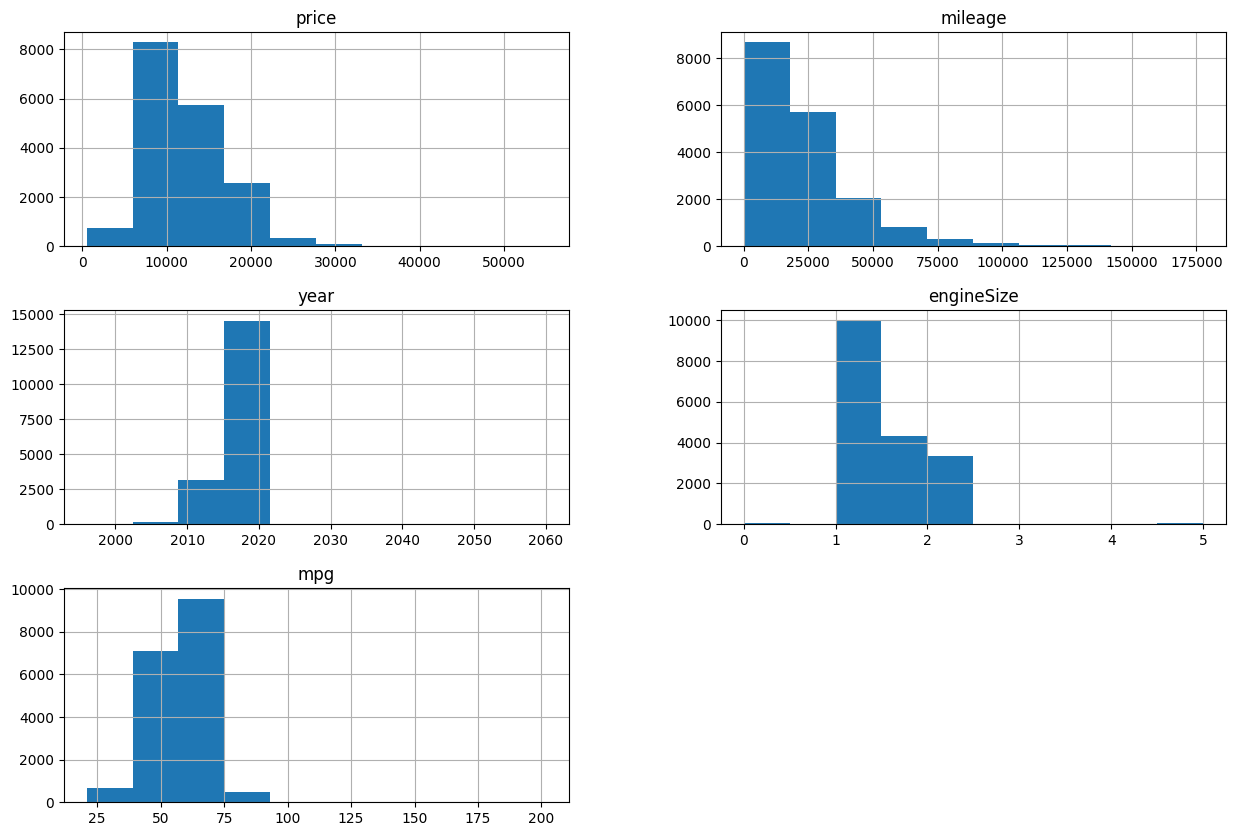

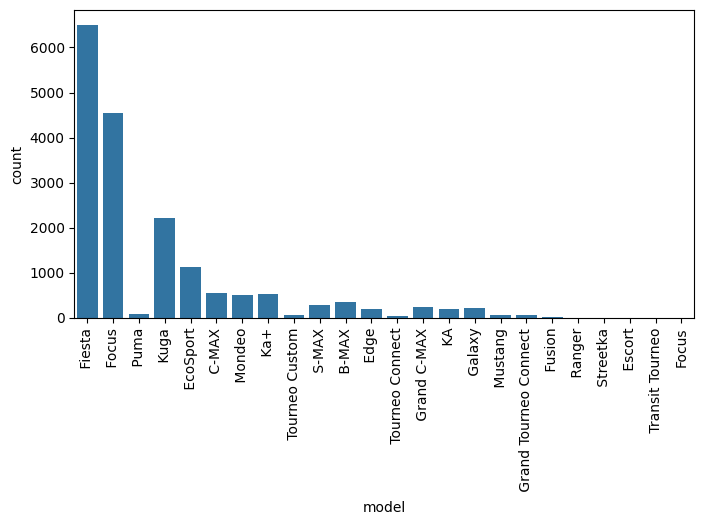

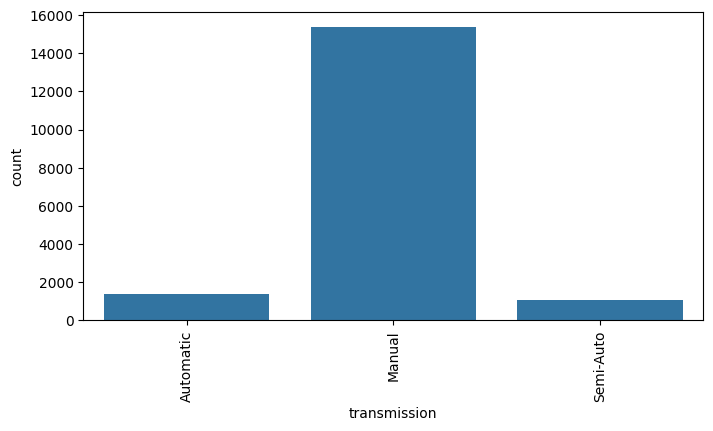

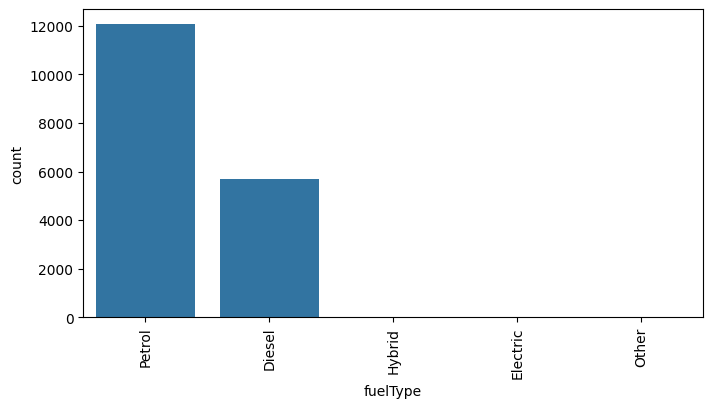

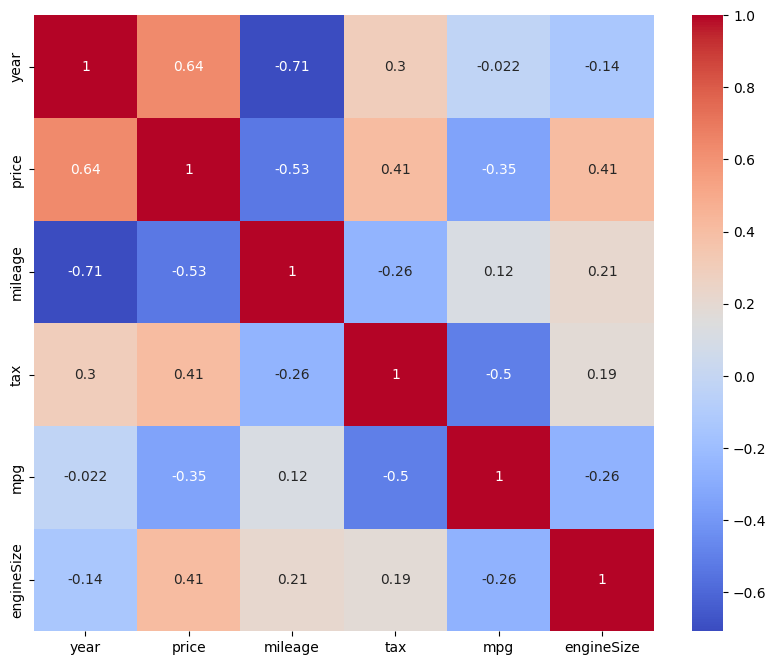

Final Shape of X: (17812, 34)
Target Shape: (17812,)


,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.020597,-0.810561,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,0.554393,-0.736317,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.067059,-0.562616,0.591380,-0.020597,-0.810561,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.041726,-0.665405,0.510777,-1.737858,0.345325,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,1.041726,-1.127749,0.510777,-0.908836,-0.810561,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


,price
0,12000
1,14000
2,13000
3,17500
4,16500


In [16]:

df = pd.read_csv("ford_car_dataset.csv")
df = df.dropna()
df = df.drop_duplicates()
df[['price','mileage','year','engineSize','mpg']].hist(figsize=(15,10))
plt.show()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=90)
    plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()
X = df.drop('price', axis=1)
y = df['price']
X = pd.get_dummies(X, drop_first=True)
num_cols = ['year','mileage','tax','mpg','engineSize']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
print("Final Shape of X:", X.shape)
print("Target Shape:", y.shape)
display(X.head())
display(y.head())